In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import holidays

In [2]:
# Cargar los CSVs de ventas y competencia en sus respectivos dataframes
ventas_df = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
competencia_df = pd.read_csv('../data/raw/entrenamiento/competencia.csv')

In [3]:
# Mostrar los primeros registros de los dataframes
print('Primeros registros de ventas_df:')
display(ventas_df.head())
print('Primeros registros de competencia_df:')
display(competencia_df.head())

Primeros registros de ventas_df:


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


Primeros registros de competencia_df:


,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [4]:
# Validación de la calidad de datos del dataframe ventas_df
print('--- Informe de calidad de datos: ventas_df ---')

# Tipos de variables
tipos = ventas_df.dtypes
print('Tipos de variables:')
print(tipos)

# Nulos
nulos = ventas_df.isnull().sum()
print('\nValores nulos por columna:')
print(nulos)

# Duplicados
duplicados = ventas_df.duplicated().sum()
print(f'\nFilas duplicadas: {duplicados}')

# Descriptivos
descriptivos = ventas_df.describe(include='all')
print('\nEstadísticas descriptivas:')
print(descriptivos)

# Resumen final
def calidad_ventas(df):
    resumen = {}
    resumen['tipos'] = df.dtypes.to_dict()
    resumen['nulos'] = df.isnull().sum().to_dict()
    resumen['duplicados'] = df.duplicated().sum()
    resumen['descriptivos'] = df.describe(include='all').to_dict()
    return resumen

informe = calidad_ventas(ventas_df)
print('\n--- Resumen final de calidad de datos ---')
for clave, valor in informe.items():
    print(f'{clave}:')
    print(valor)
    print('')

--- Informe de calidad de datos: ventas_df ---
Tipos de variables:
fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

Valores nulos por columna:
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

Filas duplicadas: 0

Estadísticas descriptivas:
             fecha producto_id                    nombre categoria  \
count         3552        3552                      3552      3552   
unique         148          24                        24         4   
top     2021-10-25    PROD_001  Nike Air Zoom Pegasus 40   Running   
freq            24         14

In [5]:
# Validación de la calidad de datos del dataframe competencia_df
print('--- Informe de calidad de datos: competencia_df ---')

# Tipos de variables
tipos = competencia_df.dtypes
print('Tipos de variables:')
print(tipos)

# Nulos
nulos = competencia_df.isnull().sum()
print('\nValores nulos por columna:')
print(nulos)

# Duplicados
duplicados = competencia_df.duplicated().sum()
print(f'\nFilas duplicadas: {duplicados}')

# Descriptivos
descriptivos = competencia_df.describe(include='all')
print('\nEstadísticas descriptivas:')
print(descriptivos)

# Resumen final
def calidad_competencia(df):
    resumen = {}
    resumen['tipos'] = df.dtypes.to_dict()
    resumen['nulos'] = df.isnull().sum().to_dict()
    resumen['duplicados'] = df.duplicated().sum()
    resumen['descriptivos'] = df.describe(include='all').to_dict()
    return resumen

informe = calidad_competencia(competencia_df)
print('\n--- Resumen final de calidad de datos ---')
for clave, valor in informe.items():
    print(f'{clave}:')
    print(valor)
    print('')

--- Informe de calidad de datos: competencia_df ---
Tipos de variables:
fecha            object
producto_id      object
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object

Valores nulos por columna:
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

Filas duplicadas: 0

Estadísticas descriptivas:
             fecha producto_id       Amazon    Decathlon  Deporvillage
count         3552        3552  3552.000000  3552.000000   3552.000000
unique         148          24          NaN          NaN           NaN
top     2021-10-25    PROD_001          NaN          NaN           NaN
freq            24         148          NaN          NaN           NaN
mean           NaN         NaN   118.623407   111.412182    118.894628
std            NaN         NaN   156.095628   148.508132    160.216448
min            NaN         NaN    16.850000    15.450000     16.770000
25%            NaN         NaN    47.117500   

In [6]:
# Convertir la variable fecha a tipo datetime en ambos dataframes
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'])

# Verificar la conversión
display(ventas_df['fecha'].head())
display(competencia_df['fecha'].head())

0   2021-10-25
1   2021-10-25
2   2021-10-25
3   2021-10-25
4   2021-10-25
Name: fecha, dtype: datetime64[ns]

0   2021-10-25
1   2021-10-25
2   2021-10-25
3   2021-10-25
4   2021-10-25
Name: fecha, dtype: datetime64[ns]

In [7]:
ventas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB


In [8]:
competencia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 138.9+ KB


In [9]:
# Crear un nuevo dataframe DF que une ventas_df y competencia_df por fecha y producto_id
df = pd.merge(ventas_df, competencia_df, on=['fecha', 'producto_id'], how='inner')

# Mostrar los primeros registros del nuevo dataframe
print('Primeros registros del dataframe DF:')
display(df.head())

Primeros registros del dataframe DF:


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


## EDA
Analisis exploratorio completo de df

In [10]:
# 🤖 Análisis exploratorio completo del DataFrame df
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.holiday import USFederalHolidayCalendar
import holidays

# Aseguramos que la columna de fecha esté en formato datetime
if not np.issubdtype(df['fecha'].dtype, np.datetime64):
    df['fecha'] = pd.to_datetime(df['fecha'])

# Creamos una columna de año para los gráficos por año
df['año'] = df['fecha'].dt.year

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage,año
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43,2021
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58,2021
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11,2021
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45,2021
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07,2021


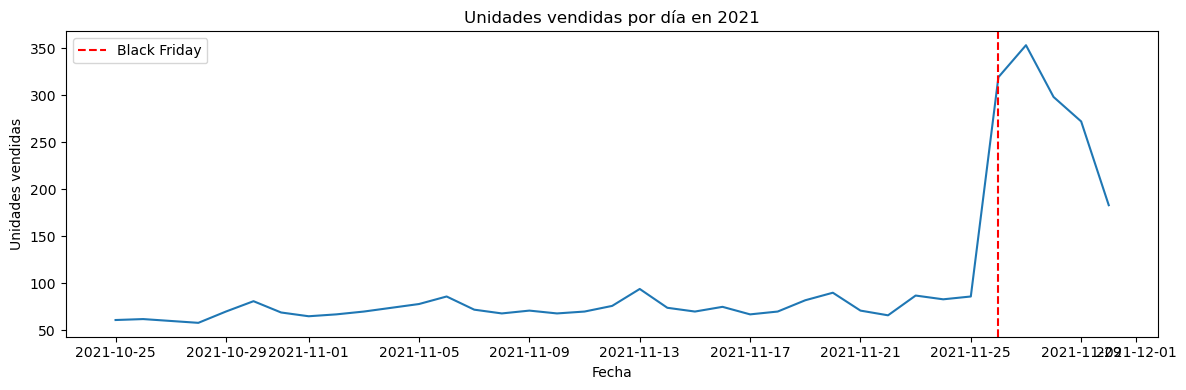

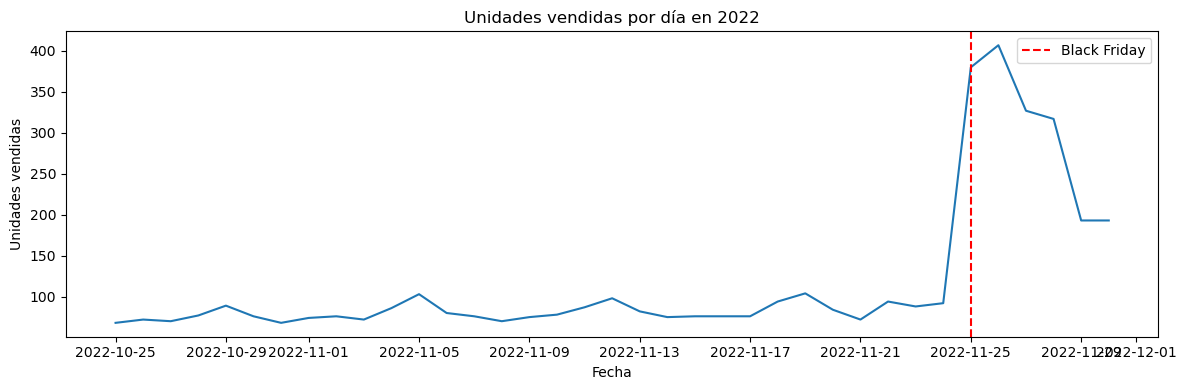

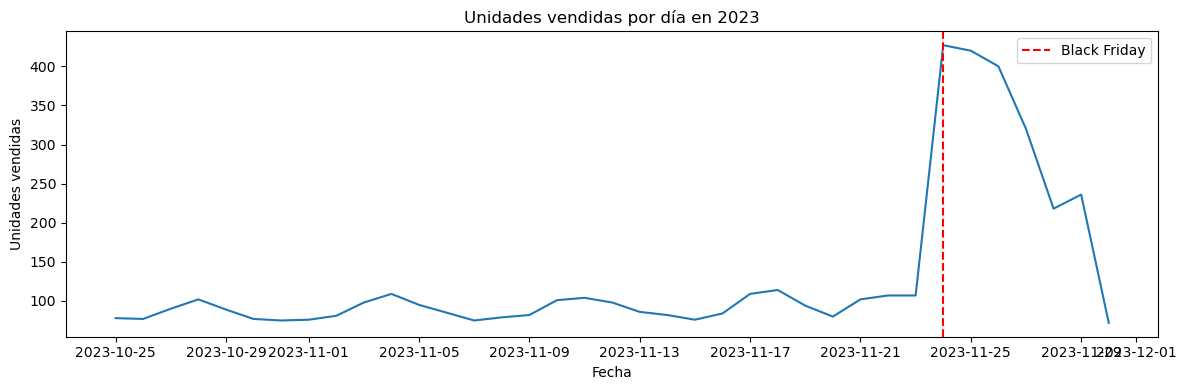

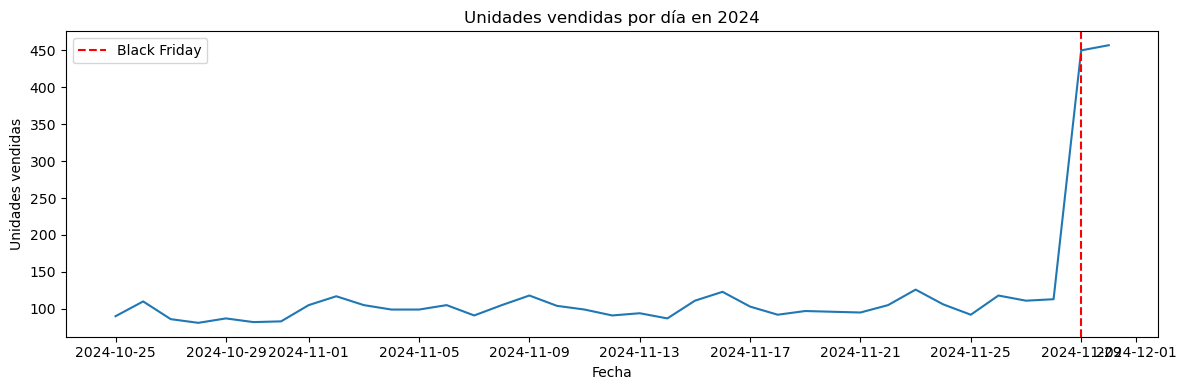

In [11]:
# 🤖 Gráfico de líneas temporales de unidades vendidas por año, marcando Black Friday

# Identificamos los años únicos en el DataFrame
años = df['año'].unique()

# Función para calcular el cuarto viernes de noviembre (Black Friday)
def get_black_friday(year):
    bf_date = []
    nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    fridays = nov[nov.weekday == 4]
    bf_date.append(fridays[-1])
    return bf_date # cuarto viernes

black_friday_dates = {a: get_black_friday(a) for a in años}

# Graficamos por año
for a in sorted(años):
    plt.figure(figsize=(12, 4))
    datos = df[df['año'] == a].groupby('fecha')['unidades_vendidas'].sum()
    sns.lineplot(x=datos.index, y=datos.values)
    plt.title(f'Unidades vendidas por día en {a}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    # Marcamos Black Friday
    bf = black_friday_dates[a]
    plt.axvline(bf, color='red', linestyle='--', label='Black Friday')
    plt.legend()
    plt.tight_layout()
    plt.show()

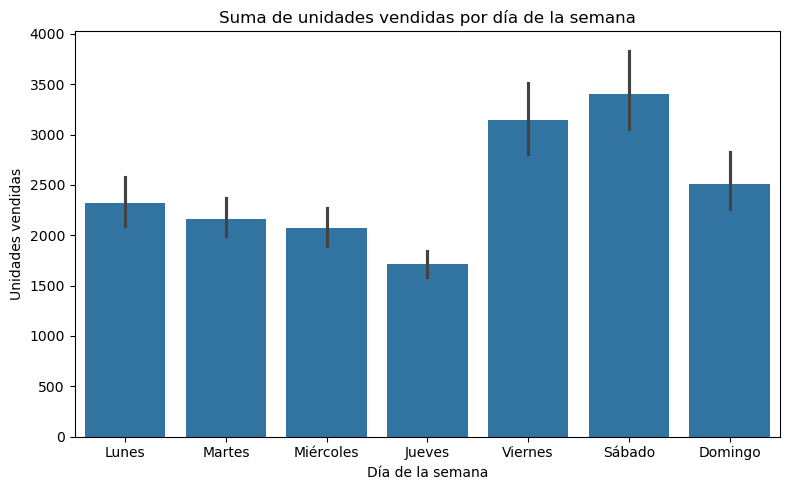

In [12]:
# 🤖 Gráfico de suma de unidades vendidas por día de la semana

df['dia_semana'] = df['fecha'].dt.day_name(locale='es')
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orden_dias_es = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
# Si los días están en inglés, traducimos
if set(df['dia_semana'].unique()) == set(orden_dias):
    traduccion = dict(zip(orden_dias, orden_dias_es))
    df['dia_semana'] = df['dia_semana'].map(traduccion)

plt.figure(figsize=(8, 5))
sns.barplot(x='dia_semana', y='unidades_vendidas', data=df, estimator=sum, order=orden_dias_es)
plt.title('Suma de unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.tight_layout()
plt.show()

C:\Users\rosal\AppData\Local\Temp\ipykernel_1632\2473086077.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
C:\Users\rosal\AppData\Local\Temp\ipykernel_1632\2473086077.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


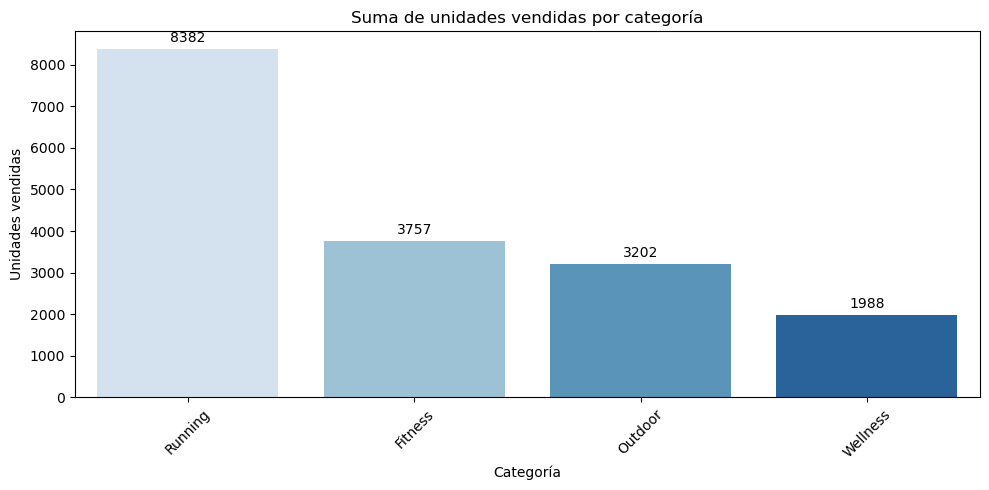

In [13]:
# 🤖 Gráfico de suma de unidades vendidas por categoría (azul degradado + etiquetas)
orden_categorias = df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).index
palette_azules = sns.color_palette("Blues", n_colors=len(orden_categorias))

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x='categoria',
    y='unidades_vendidas',
    data=df,
    estimator=sum,
    ci=None,
    order=orden_categorias,
    palette=palette_azules
)
plt.title('Suma de unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

C:\Users\rosal\AppData\Local\Temp\ipykernel_1632\1791813891.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='subcategoria', y='unidades_vendidas', data=df, estimator=sum, ci=None, order=df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)


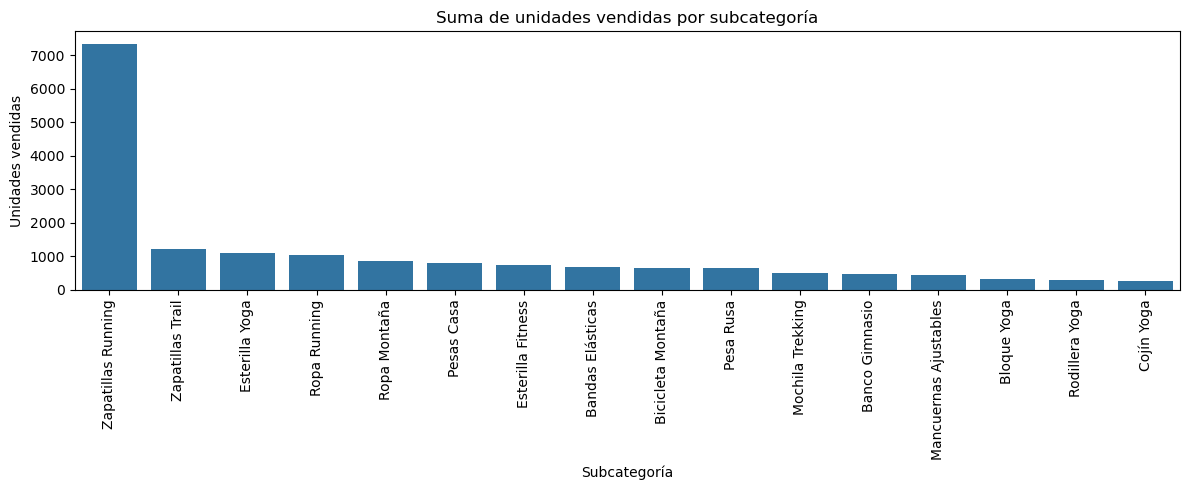

In [14]:
# 🤖 Gráfico de suma de unidades vendidas por subcategoría
plt.figure(figsize=(12, 5))
sns.barplot(x='subcategoria', y='unidades_vendidas', data=df, estimator=sum, ci=None, order=df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)
plt.title('Suma de unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage,año,dia_semana
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43,2021,Lunes
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58,2021,Lunes
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11,2021,Lunes
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45,2021,Lunes
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07,2021,Lunes


C:\Users\rosal\AppData\Local\Temp\ipykernel_1632\1503580428.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=top_col, y='unidades_vendidas', data=df[df[top_col].isin(top_productos)], estimator=sum, ci=None, order=top_productos)


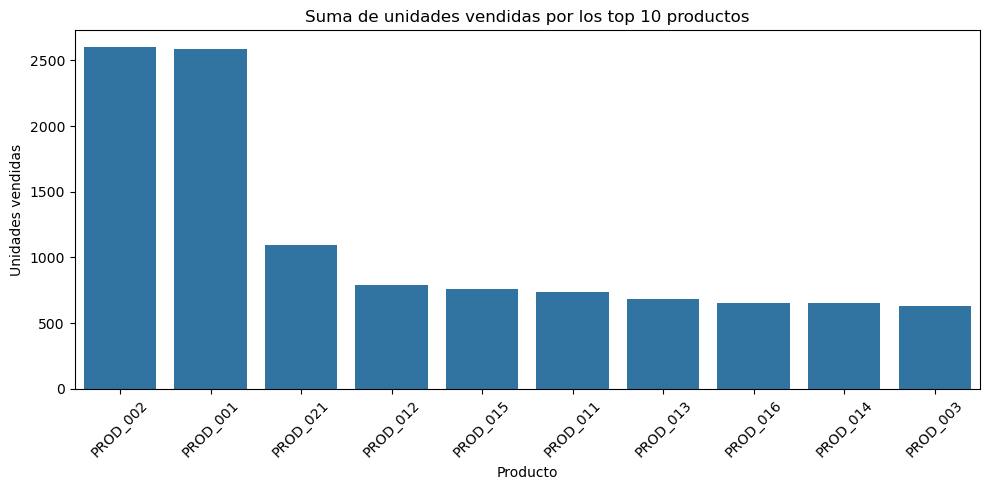

In [15]:
# 🤖 Gráfico de suma de unidades vendidas por los top 10 productos
# Buscamos el nombre correcto de la columna de producto
display(df.head())  # Mostramos las primeras filas para identificar el nombre correcto

# Si la columna se llama 'producto_id', usamos esa columna para el análisis de top productos
top_col = 'producto'
if 'producto' not in df.columns:
    if 'producto_id' in df.columns:
        top_col = 'producto_id'
    else:
        raise KeyError('No se encuentra la columna de producto o producto_id en el DataFrame')

top_productos = df.groupby(top_col)['unidades_vendidas'].sum().sort_values(ascending=False).head(10).index
plt.figure(figsize=(10, 5))
sns.barplot(x=top_col, y='unidades_vendidas', data=df[df[top_col].isin(top_productos)], estimator=sum, ci=None, order=top_productos)
plt.title('Suma de unidades vendidas por los top 10 productos')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

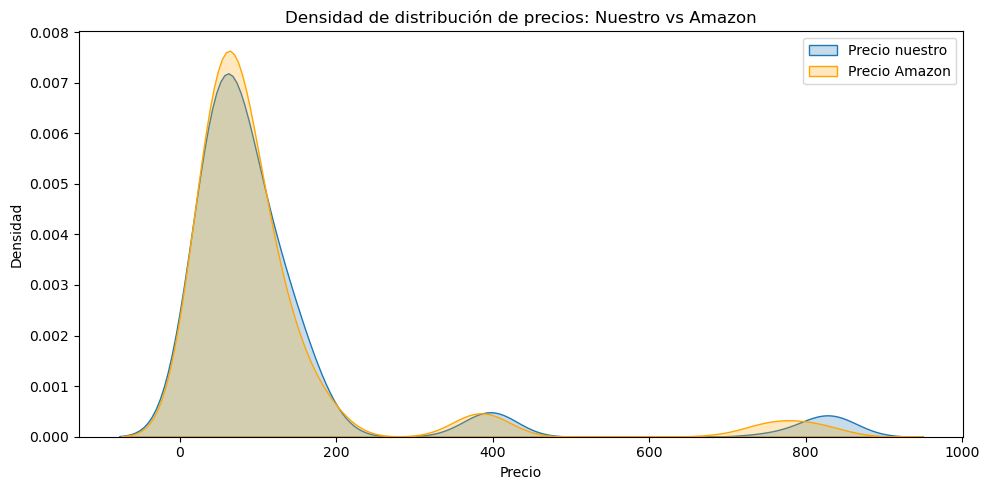

In [16]:
# 🤖 Análisis de densidad de distribución de precios propios y de Amazon (competencia)
plt.figure(figsize=(10, 5))
sns.kdeplot(df['precio_venta'], label='Precio nuestro', fill=True)
sns.kdeplot(df['Amazon'], label='Precio Amazon', fill=True, color='orange')
plt.title('Densidad de distribución de precios: Nuestro vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# 🤖 Creación de variables temporales y de calendario para España
import holidays

df['año'] = df['fecha'].dt.year

# Mes y nombre del mes
df['mes'] = df['fecha'].dt.month
meses_es = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
df['nombre_mes'] = df['mes'].apply(lambda x: meses_es[x-1])

# Día del mes y día de la semana
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
dias_es = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df['nombre_dia_semana'] = df['dia_semana'].apply(lambda x: dias_es[x])

# Es fin de semana
df['es_fin_de_semana'] = df['dia_semana'].isin([5,6])

# Festivos nacionales en España
festivos_es = holidays.country_holidays('ES', years=df['año'].unique())
df['es_festivo'] = df['fecha'].isin(festivos_es)

# Black Friday (cuarto viernes de noviembre)
def es_black_friday(fecha):
    if fecha.month == 11 and fecha.weekday() == 4:
        # ¿Es el cuarto viernes?
        primer_dia = fecha.replace(day=1)
        fridays = [d for d in pd.date_range(primer_dia, fecha, freq='W-FRI')]
        return len(fridays) == 4
    return False
df['es_Black_Friday'] = df['fecha'].apply(es_black_friday)

# Cyber Monday (primer lunes después de Black Friday)
def es_cyber_monday(fecha):
    if fecha.month == 11 or fecha.month == 12:
        # Buscar el Black Friday de ese año
        year = fecha.year
        nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
        fridays = nov[nov.weekday == 4]
        if len(fridays) >= 4:
            black_friday = fridays[3]
            cyber_monday = black_friday + pd.Timedelta(days=3)
            return fecha == cyber_monday
    return False
df['es_Cyber_Monday'] = df['fecha'].apply(es_cyber_monday)

# Día laborable (no festivo y no fin de semana)
df['es_laborable'] = (~df['es_festivo']) & (~df['es_fin_de_semana'])

# Día del año
df['dia_del_año'] = df['fecha'].dt.dayofyear

# Semana del año
df['semana_del_año'] = df['fecha'].dt.isocalendar().week

df.head()

C:\Users\rosal\AppData\Local\Temp\ipykernel_1632\4091124097.py:22: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_festivo'] = df['fecha'].isin(festivos_es)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,nombre_mes,dia_mes,nombre_dia_semana,es_fin_de_semana,es_festivo,es_Black_Friday,es_Cyber_Monday,es_laborable,dia_del_año,semana_del_año
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,Octubre,25,Lunes,False,False,False,False,True,298,43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,Octubre,25,Lunes,False,False,False,False,True,298,43
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,Octubre,25,Lunes,False,False,False,False,True,298,43
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,Octubre,25,Lunes,False,False,False,False,True,298,43
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,Octubre,25,Lunes,False,False,False,False,True,298,43


In [18]:
df.shape

(3552, 26)

In [19]:
# 🤖 Creación de lags (1 a 7) y media móvil 7 días de unidades vendidas, por año (sin mezclar años)

# Definir los grupos para no mezclar años ni productos
if 'producto_id' in df.columns:
    grupos = ['producto_id', 'año']
else:
    grupos = ['año']
df = df.sort_values(grupos + ['fecha'])

# Crear lags del 1 al 7or lag in range(1, 8):
for lag in range(1, 8):
    df[f'unidades_vendidas_lag{lag}'] = df.groupby(grupos)['unidades_vendidas'].shift(lag)

# Media móvil 7 días
    
df['unidades_vendidas_mm7'] = df.groupby(grupos)['unidades_vendidas'].transform(lambda x: x.rolling(7, min_periods=1).mean())

# Eliminar registros con nulos en los nuevos lags o media móvil
lag_cols = [f'unidades_vendidas_lag{i}' for i in range(1, 8)] + ['unidades_vendidas_mm7']
df = df.dropna(subset=lag_cols)

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,dia_del_año,semana_del_año,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7
168,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,305,44,9.0,12.0,12.0,7.0,8.0,8.0,6.0,9.000000
192,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,306,44,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.285714
216,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,307,44,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.714286
240,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,112.23,1346.76,...,308,44,11.0,10.0,7.0,9.0,12.0,12.0,7.0,10.428571
264,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,113.81,1138.10,...,309,44,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.142857


In [20]:
df.shape

(2880, 34)

In [21]:
df.groupby('año').size()

año
2021    720
2022    720
2023    720
2024    720
dtype: int64

In [22]:
df.groupby('producto_id').size()

producto_id
PROD_001    120
PROD_002    120
PROD_003    120
PROD_004    120
PROD_005    120
PROD_006    120
PROD_007    120
PROD_008    120
PROD_009    120
PROD_010    120
PROD_011    120
PROD_012    120
PROD_013    120
PROD_014    120
PROD_015    120
PROD_016    120
PROD_017    120
PROD_018    120
PROD_019    120
PROD_020    120
PROD_021    120
PROD_022    120
PROD_023    120
PROD_024    120
dtype: int64

In [23]:
print(df[lag_cols+['producto_id','fecha','año','unidades_vendidas']].head(10))

     unidades_vendidas_lag1  unidades_vendidas_lag2  unidades_vendidas_lag3  \
168                     9.0                    12.0                    12.0   
192                     7.0                     9.0                    12.0   
216                    10.0                     7.0                     9.0   
240                    11.0                    10.0                     7.0   
264                    12.0                    11.0                    10.0   
288                    10.0                    12.0                    11.0   
312                    10.0                    10.0                    12.0   
336                    10.0                    10.0                    10.0   
360                     9.0                    10.0                    10.0   
384                    11.0                     9.0                    10.0   

     unidades_vendidas_lag4  unidades_vendidas_lag5  unidades_vendidas_lag6  \
168                     7.0                     8.0

In [24]:
# 🤖 Creación de variable de descuento porcentual respecto al precio base
# Se asume que las columnas se llaman 'precio_base' y 'precio_venta'. 
if 'precio_base' in df.columns and 'precio_venta' in df.columns:
    df['descuento_pct'] = (df['precio_venta'] - df['precio_base']) / df['precio_base'] * 100
else:
    print('⚠️ Las columnas precio_base y/o precio_venta no existen en el DataFrame.')
df[['fecha','producto_id','precio_base','precio_venta','descuento_pct']].head(20)

,fecha,producto_id,precio_base,precio_venta,descuento_pct
168,2021-11-01,PROD_001,115,115.07,0.060870
192,2021-11-02,PROD_001,115,116.10,0.956522
216,2021-11-03,PROD_001,115,114.58,-0.365217
240,2021-11-04,PROD_001,115,112.23,-2.408696
264,2021-11-05,PROD_001,115,113.81,-1.034783
288,2021-11-06,PROD_001,115,117.80,2.434783
312,2021-11-07,PROD_001,115,116.04,0.904348
336,2021-11-08,PROD_001,115,113.46,-1.339130
360,2021-11-09,PROD_001,115,113.98,-0.886957
384,2021-11-10,PROD_001,115,117.57,2.234783


In [25]:
# 🤖 Crear variable precio_competencia y ratio_precio, y eliminar columnas de competidores
competidores = ['Amazon', 'Decathlon', 'Deporvillage']
# Calcular el precio promedio de la competencia
if all(col in df.columns for col in competidores):
    df['precio_competencia'] = df[competidores].mean(axis=1)
    # Ratio de nuestro precio respecto a la competencia
    if 'precio_venta' in df.columns:
        df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']
    else:
        print('⚠️ La columna precio_venta no existe en el DataFrame.')
    # Eliminar columnas de los competidores
    df = df.drop(columns=competidores)
else:
    print('⚠️ Alguna columna de competidor no existe en el DataFrame.')
df[['fecha','producto_id','precio_base','precio_venta','descuento_pct','precio_competencia','ratio_precio']].head(20)

,fecha,producto_id,precio_base,precio_venta,descuento_pct,precio_competencia,ratio_precio
168,2021-11-01,PROD_001,115,115.07,0.060870,95.353333,1.206775
192,2021-11-02,PROD_001,115,116.10,0.956522,96.153333,1.207446
216,2021-11-03,PROD_001,115,114.58,-0.365217,95.240000,1.203066
240,2021-11-04,PROD_001,115,112.23,-2.408696,96.590000,1.161922
264,2021-11-05,PROD_001,115,113.81,-1.034783,96.170000,1.183425
288,2021-11-06,PROD_001,115,117.80,2.434783,95.436667,1.234326
312,2021-11-07,PROD_001,115,116.04,0.904348,96.153333,1.206822
336,2021-11-08,PROD_001,115,113.46,-1.339130,97.003333,1.169651
360,2021-11-09,PROD_001,115,113.98,-0.886957,96.933333,1.175860
384,2021-11-10,PROD_001,115,117.57,2.234783,96.343333,1.220323


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2880 entries, 168 to 3551
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   fecha                   2880 non-null   datetime64[ns]
 1   producto_id             2880 non-null   object        
 2   nombre                  2880 non-null   object        
 3   categoria               2880 non-null   object        
 4   subcategoria            2880 non-null   object        
 5   precio_base             2880 non-null   int64         
 6   es_estrella             2880 non-null   bool          
 7   unidades_vendidas       2880 non-null   int64         
 8   precio_venta            2880 non-null   float64       
 9   ingresos                2880 non-null   float64       
 10  año                     2880 non-null   int32         
 11  dia_semana              2880 non-null   int32         
 12  mes                     2880 non-null   int32      

In [27]:
# 🤖 Crear copias de variables y aplicar One Hot Encoding
# Crear copias con sufijo _H
for col in ['nombre', 'categoria', 'subcategoria']:
    if col in df.columns:
        df[col + '_H'] = df[col]
    else:
        print(f'⚠️ La columna {col} no existe en el DataFrame.')

# One Hot Encoding sobre las nuevas columnas
cols_h = [c for c in ['nombre_H', 'categoria_H', 'subcategoria_H'] if c in df.columns]
df = pd.get_dummies(df, columns=cols_h, drop_first=False)
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_H_Esterilla Yoga,subcategoria_H_Mancuernas Ajustables,subcategoria_H_Mochila Trekking,subcategoria_H_Pesa Rusa,subcategoria_H_Pesas Casa,subcategoria_H_Rodillera Yoga,subcategoria_H_Ropa Montaña,subcategoria_H_Ropa Running,subcategoria_H_Zapatillas Running,subcategoria_H_Zapatillas Trail
168,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,False,False,False,False,False,False,False,False,True,False
192,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,False,False,False,False,False,False,False,False,True,False
216,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,False,False,False,False,False,False,False,False,True,False
240,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,112.23,1346.76,...,False,False,False,False,False,False,False,False,True,False
264,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,113.81,1138.10,...,False,False,False,False,False,False,False,False,True,False


In [28]:
df.to_csv('../data/processed/df.csv', index=False)
print('DataFrame procesado guardado en ../data/processed/df.csv')

DataFrame procesado guardado en ../data/processed/df.csv


In [29]:
# 🤖 División de df en train_df (2021-2023) y validation_df (2024)
train_df = df[df['año'].isin([2021, 2022, 2023])].copy()
validation_df = df[df['año'] == 2024].copy()

print(f'Registros en train_df: {train_df.shape[0]}')
print(f'Registros en validation_df: {validation_df.shape[0]}')

Registros en train_df: 2160
Registros en validation_df: 720


In [30]:
# 🤖 Entrenamiento y validación de HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selección de variables predictoras
excluir = ['fecha', 'ingresos', 'unidades_vendidas']
# Excluir variables tipo object
excluir += [col for col in train_df.columns if train_df[col].dtype == 'object']
X_train = train_df.drop(columns=excluir)
y_train = train_df['unidades_vendidas']
X_val = validation_df.drop(columns=excluir)
y_val = validation_df['unidades_vendidas']

# Modelo conservador
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    l2_regularization=1.0,
    random_state=42
)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_val)

# Baseline naive: predice la media de train
y_pred_naive = np.full_like(y_val, y_train.mean(), dtype=np.float64)

# Métricas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

mae_naive = mean_absolute_error(y_val, y_pred_naive)
mse_naive = mean_squared_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)
r2_naive = r2_score(y_val, y_pred_naive)

print('HistGradientBoostingRegressor:')
print(f'MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.3f}')
print('Baseline Naive:')
print(f'MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}, R2: {r2_naive:.3f}')

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\rosal\miniconda3\envs\Forecasting\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\rosal\miniconda3\envs\Forecasting\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\rosal\miniconda3\envs\Forecasting\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 116: invalid start byte


HistGradientBoostingRegressor:
MAE: 0.95, RMSE: 1.88, R2: 0.921
Baseline Naive:
MAE: 3.67, RMSE: 6.69, R2: -0.000


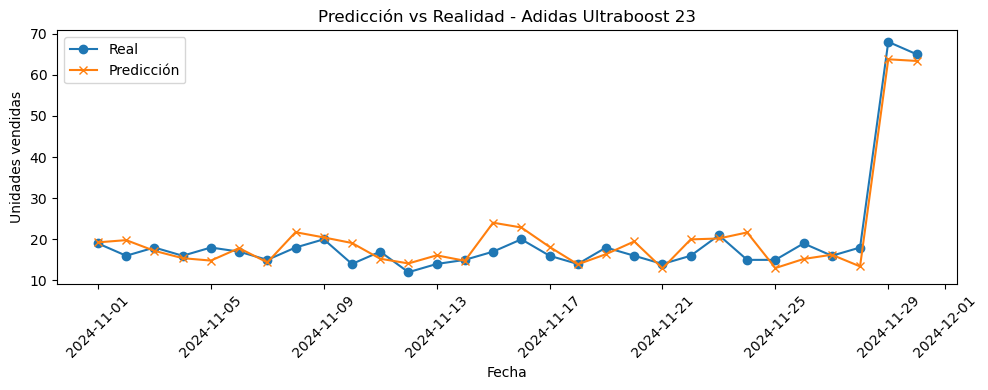

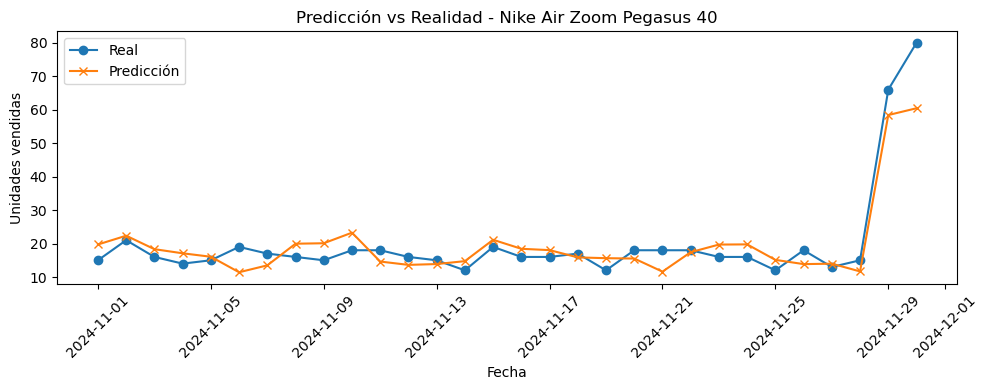

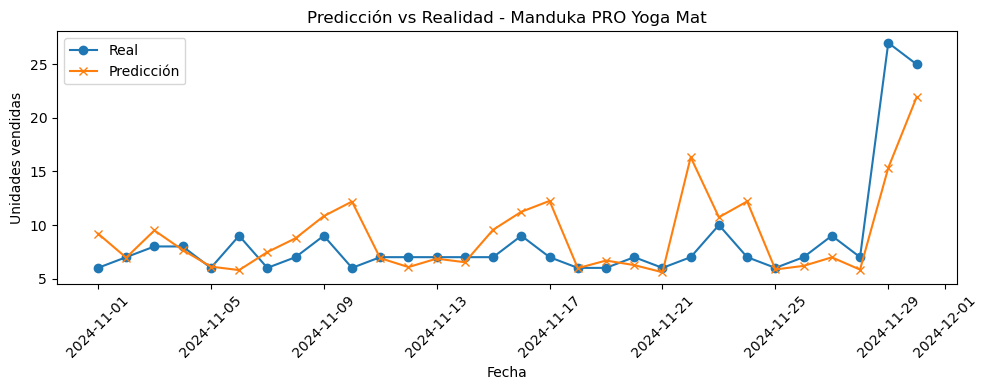

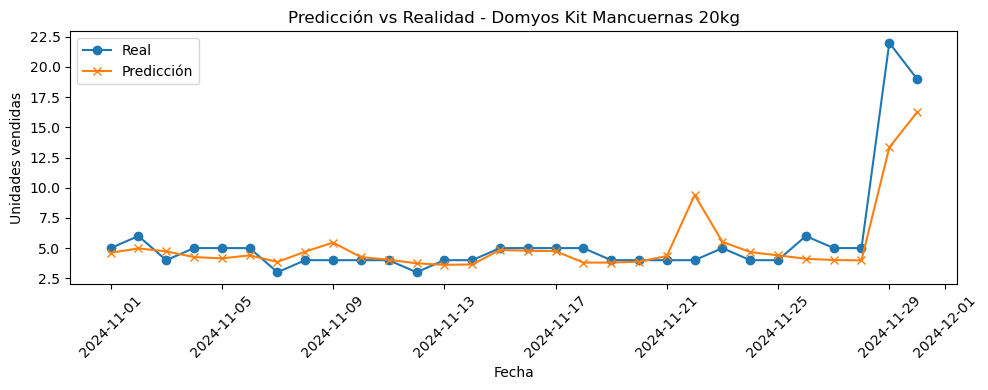

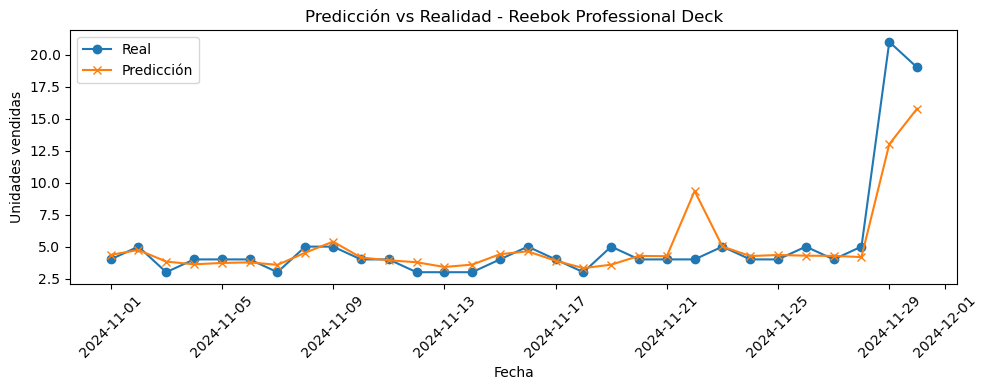

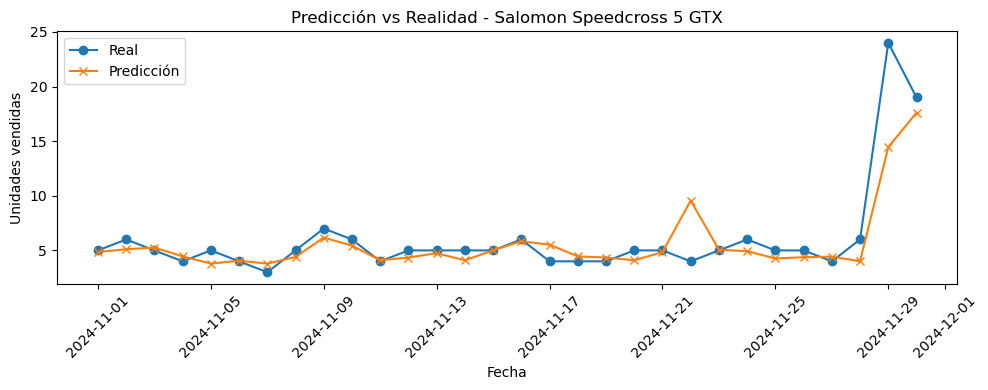

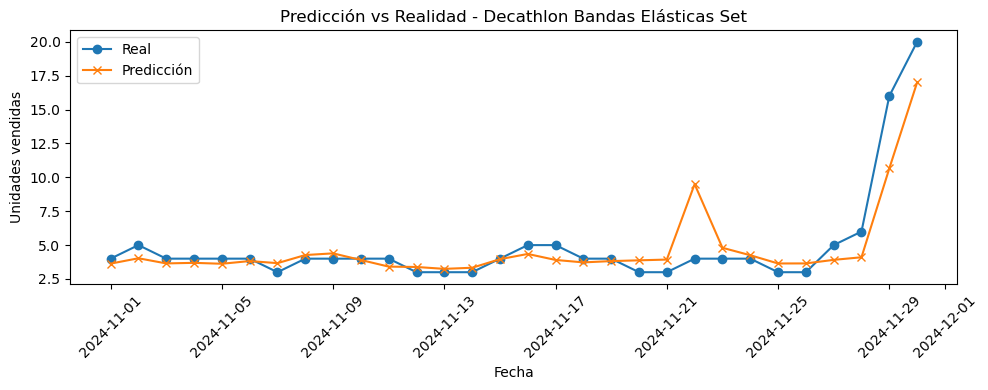

In [31]:
# 🤖 Predicción y visualización para los 7 productos estrella en noviembre 2024
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos los 7 productos estrella por ventas totales en train_df
if 'producto_id' in df.columns:
    top_productos = train_df.groupby('producto_id')['unidades_vendidas'].sum().sort_values(ascending=False).head(7).index
    nombre_col = 'producto_id'
elif 'producto' in df.columns:
    top_productos = train_df.groupby('producto')['unidades_vendidas'].sum().sort_values(ascending=False).head(7).index
    nombre_col = 'producto'
else:
    raise ValueError('No se encuentra columna de producto o producto_id')

# Filtramos noviembre 2024
df_nov2024 = validation_df[(validation_df['fecha'] >= '2024-11-01') & (validation_df['fecha'] <= '2024-11-30')]

# Variables predictoras
excluir = ['fecha', 'ingresos', 'unidades_vendidas']
excluir += [col for col in df_nov2024.columns if df_nov2024[col].dtype == 'object']

for prod in top_productos:
    datos_prod = df_nov2024[df_nov2024[nombre_col] == prod].copy()
    if datos_prod.empty:
        print(f'No hay datos para el producto {prod} en noviembre 2024')
        continue
    X_prod = datos_prod.drop(columns=excluir)
    y_real = datos_prod['unidades_vendidas']
    y_pred = model.predict(X_prod)
    # Nombre legible
    nombre_legible = prod
    if 'nombre' in datos_prod.columns:
        nombre_legible = datos_prod['nombre'].iloc[0]
    plt.figure(figsize=(10, 4))
    plt.plot(datos_prod['fecha'], y_real, label='Real', marker='o')
    plt.plot(datos_prod['fecha'], y_pred, label='Predicción', marker='x')
    plt.title(f'Predicción vs Realidad - {nombre_legible}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [32]:
# 🤖 Cálculo del MAE para cada producto estrella en noviembre 2024
from sklearn.metrics import mean_absolute_error
mae_dict = {}
for prod in top_productos:
    datos_prod = df_nov2024[df_nov2024[nombre_col] == prod].copy()
    if datos_prod.empty:
        print(f'No hay datos para el producto {prod} en noviembre 2024')
        continue
    X_prod = datos_prod.drop(columns=excluir)
    y_real = datos_prod['unidades_vendidas']
    y_pred = model.predict(X_prod)
    mae = mean_absolute_error(y_real, y_pred)
    nombre_legible = prod
    if 'nombre' in datos_prod.columns:
        nombre_legible = datos_prod['nombre'].iloc[0]
    mae_dict[nombre_legible] = mae

for nombre, mae in mae_dict.items():
    print(f'MAE para {nombre}: {mae:.2f}')

MAE para Adidas Ultraboost 23: 2.39
MAE para Nike Air Zoom Pegasus 40: 3.82
MAE para Manduka PRO Yoga Mat: 2.24
MAE para Domyos Kit Mancuernas 20kg: 1.13
MAE para Reebok Professional Deck: 0.93
MAE para Salomon Speedcross 5 GTX: 1.09
MAE para Decathlon Bandas Elásticas Set: 0.96


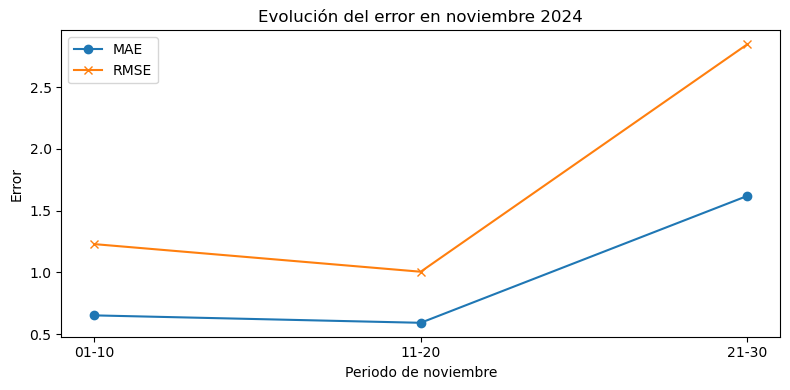

Periodo 01-10: MAE=0.65, RMSE=1.23
Periodo 11-20: MAE=0.59, RMSE=1.01
Periodo 21-30: MAE=1.62, RMSE=2.85


In [34]:
# 🤖 Análisis de la degradación del error a lo largo de noviembre 2024
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Definir los 3 periodos de 10 días
periodos = [
    ('2024-11-01', '2024-11-10'),
    ('2024-11-11', '2024-11-20'),
    ('2024-11-21', '2024-11-30')
]

mae_periodos = []
rmse_periodos = []
labels = []

for start, end in periodos:
    datos_periodo = df_nov2024[(df_nov2024['fecha'] >= start) & (df_nov2024['fecha'] <= end)]
    if datos_periodo.empty:
        mae_periodos.append(np.nan)
        rmse_periodos.append(np.nan)
        labels.append(f'{start[-2:]}-{end[-2:]}')
        continue
    X_p = datos_periodo.drop(columns=excluir)
    y_real = datos_periodo['unidades_vendidas']
    y_pred = model.predict(X_p)
    mae_periodos.append(mean_absolute_error(y_real, y_pred))
    rmse_periodos.append(np.sqrt(mean_squared_error(y_real, y_pred)))
    labels.append(f'{start[-2:]}-{end[-2:]}')

plt.figure(figsize=(8,4))
plt.plot(labels, mae_periodos, marker='o', label='MAE')
plt.plot(labels, rmse_periodos, marker='x', label='RMSE')
plt.title('Evolución del error en noviembre 2024')
plt.xlabel('Periodo de noviembre')
plt.ylabel('Error')
plt.legend()
plt.tight_layout()
plt.show()

for i, label in enumerate(labels):
    print(f'Periodo {label}: MAE={mae_periodos[i]:.2f}, RMSE={rmse_periodos[i]:.2f}')

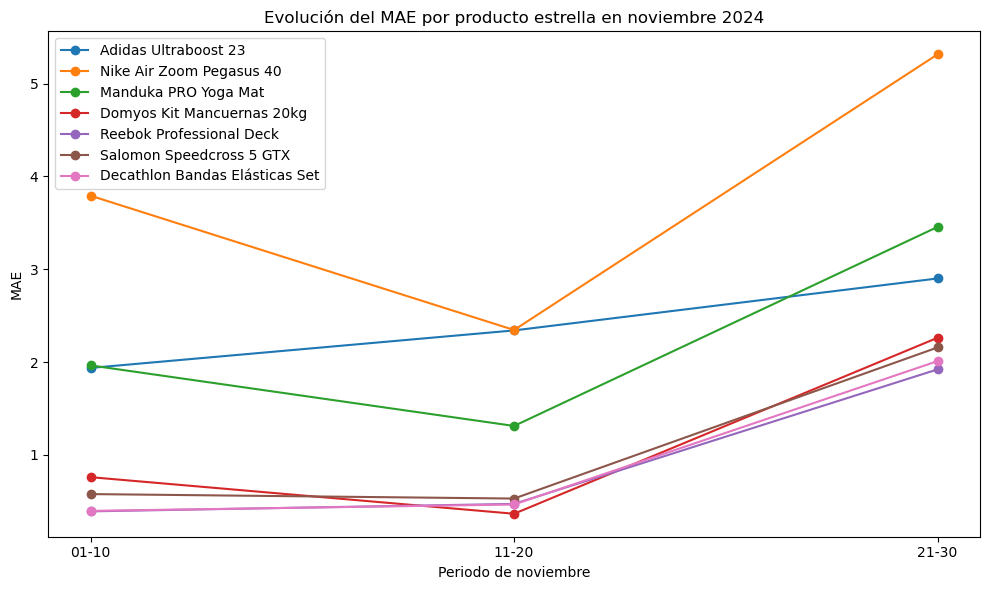

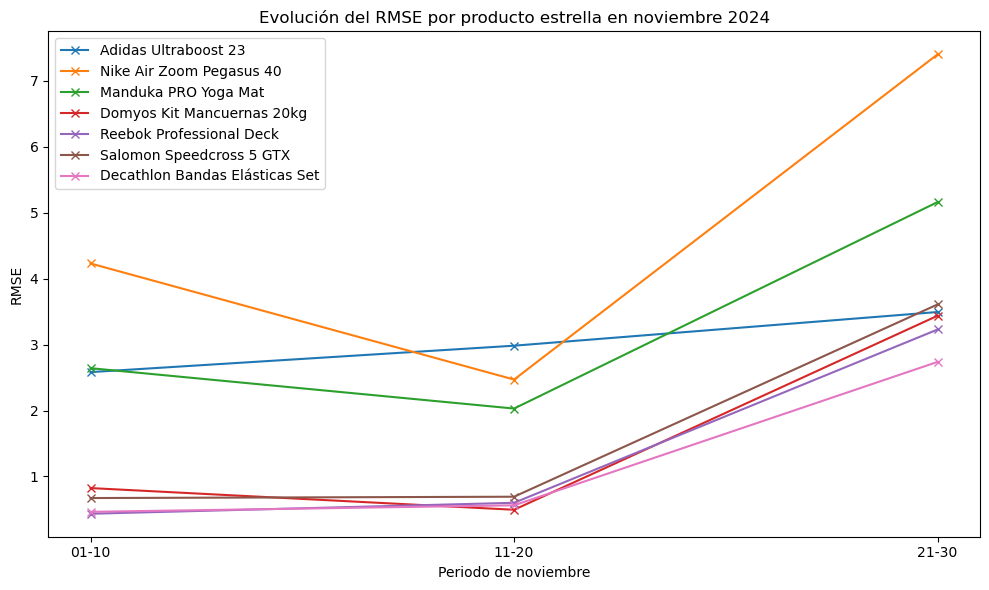

In [35]:
# 🤖 Evolución del error por producto estrella a lo largo de noviembre 2024
from sklearn.metrics import mean_absolute_error, mean_squared_error

errores_productos = {}

for prod in top_productos:
    nombre_legible = prod
    datos_prod = df_nov2024[df_nov2024[nombre_col] == prod].copy()
    if 'nombre' in datos_prod.columns and not datos_prod['nombre'].isnull().all():
        nombre_legible = datos_prod['nombre'].iloc[0]
    mae_p = []
    rmse_p = []
    for start, end in periodos:
        datos_periodo = datos_prod[(datos_prod['fecha'] >= start) & (datos_prod['fecha'] <= end)]
        if datos_periodo.empty:
            mae_p.append(np.nan)
            rmse_p.append(np.nan)
            continue
        X_p = datos_periodo.drop(columns=excluir)
        y_real = datos_periodo['unidades_vendidas']
        y_pred = model.predict(X_p)
        mae_p.append(mean_absolute_error(y_real, y_pred))
        rmse_p.append(np.sqrt(mean_squared_error(y_real, y_pred)))
    errores_productos[nombre_legible] = {'mae': mae_p, 'rmse': rmse_p}

# Gráfico de evolución del MAE por producto
plt.figure(figsize=(10,6))
for nombre, errores in errores_productos.items():
    plt.plot(labels, errores['mae'], marker='o', label=nombre)
plt.title('Evolución del MAE por producto estrella en noviembre 2024')
plt.xlabel('Periodo de noviembre')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

# Gráfico de evolución del RMSE por producto
plt.figure(figsize=(10,6))
for nombre, errores in errores_productos.items():
    plt.plot(labels, errores['rmse'], marker='x', label=nombre)
plt.title('Evolución del RMSE por producto estrella en noviembre 2024')
plt.xlabel('Periodo de noviembre')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

Black Friday 2024: 2024-11-29


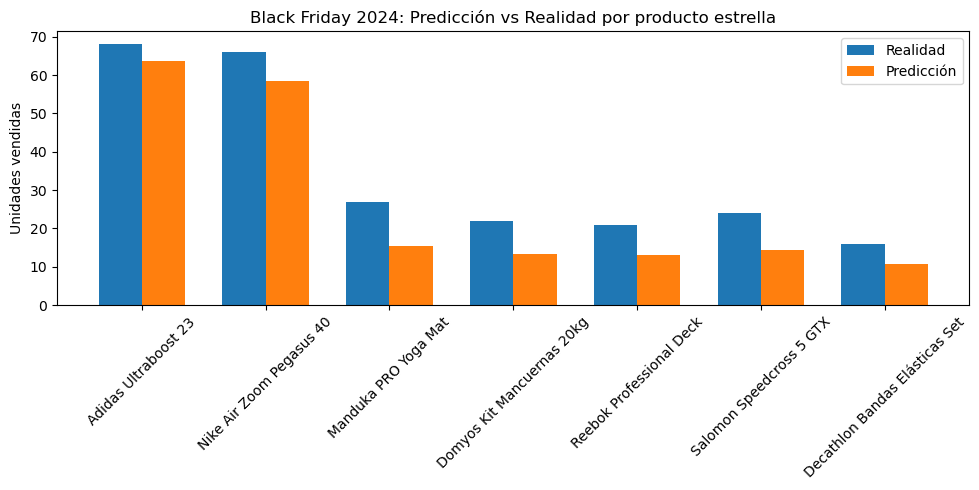

Black Friday 2024 - Unidades vendidas (realidad vs predicción):
Adidas Ultraboost 23: Real=68, Predicción=63.76
Nike Air Zoom Pegasus 40: Real=66, Predicción=58.41
Manduka PRO Yoga Mat: Real=27, Predicción=15.33
Domyos Kit Mancuernas 20kg: Real=22, Predicción=13.34
Reebok Professional Deck: Real=21, Predicción=13.01
Salomon Speedcross 5 GTX: Real=24, Predicción=14.45
Decathlon Bandas Elásticas Set: Real=16, Predicción=10.66


In [38]:
# 🤖 Análisis específico de Black Friday: comparación predicción vs realidad

# Identificar la fecha de Black Friday 2024 (último viernes de noviembre)
nov_2024 = pd.date_range(start='2024-11-01', end='2024-11-30', freq='D')
fridays = nov_2024[nov_2024.weekday == 4]
black_friday_2024 = fridays[-1] if len(fridays) > 0 else None

if black_friday_2024 is not None:
    print(f'Black Friday 2024: {black_friday_2024.date()}')
    # Filtrar datos de Black Friday
    df_bf = df_nov2024[df_nov2024['fecha'] == black_friday_2024]
    if df_bf.empty:
        print('No hay datos para Black Friday 2024 en el conjunto de validación.')
    else:
        # Predicción y realidad para los productos estrella
        productos_bf = []
        predicciones_bf = []
        realidad_bf = []
        for prod in top_productos:
            nombre_legible = prod
            datos_prod = df_bf[df_bf[nombre_col] == prod]
            if 'nombre' in datos_prod.columns and not datos_prod['nombre'].isnull().all():
                nombre_legible = datos_prod['nombre'].iloc[0]
            if datos_prod.empty:
                continue
            X_prod = datos_prod.drop(columns=excluir)
            y_real = datos_prod['unidades_vendidas'].values[0]
            y_pred = model.predict(X_prod)[0]
            productos_bf.append(nombre_legible)
            predicciones_bf.append(y_pred)
            realidad_bf.append(y_real)
        # Gráfico de barras: predicción vs realidad para cada producto estrella
        x = np.arange(len(productos_bf))
        width = 0.35
        fig, ax = plt.subplots(figsize=(10,5))
        ax.bar(x - width/2, realidad_bf, width, label='Realidad')
        ax.bar(x + width/2, predicciones_bf, width, label='Predicción')
        ax.set_xticks(x)
        ax.set_xticklabels(productos_bf, rotation=45)
        ax.set_ylabel('Unidades vendidas')
        ax.set_title('Black Friday 2024: Predicción vs Realidad por producto estrella')
        ax.legend()
        plt.tight_layout()
        plt.show()
        # Mostrar tabla de valores
        print('Black Friday 2024 - Unidades vendidas (realidad vs predicción):')
        for i, nombre in enumerate(productos_bf):
            print(f'{nombre}: Real={realidad_bf[i]}, Predicción={predicciones_bf[i]:.2f}')
else:
    print('No se pudo identificar la fecha de Black Friday 2024.')


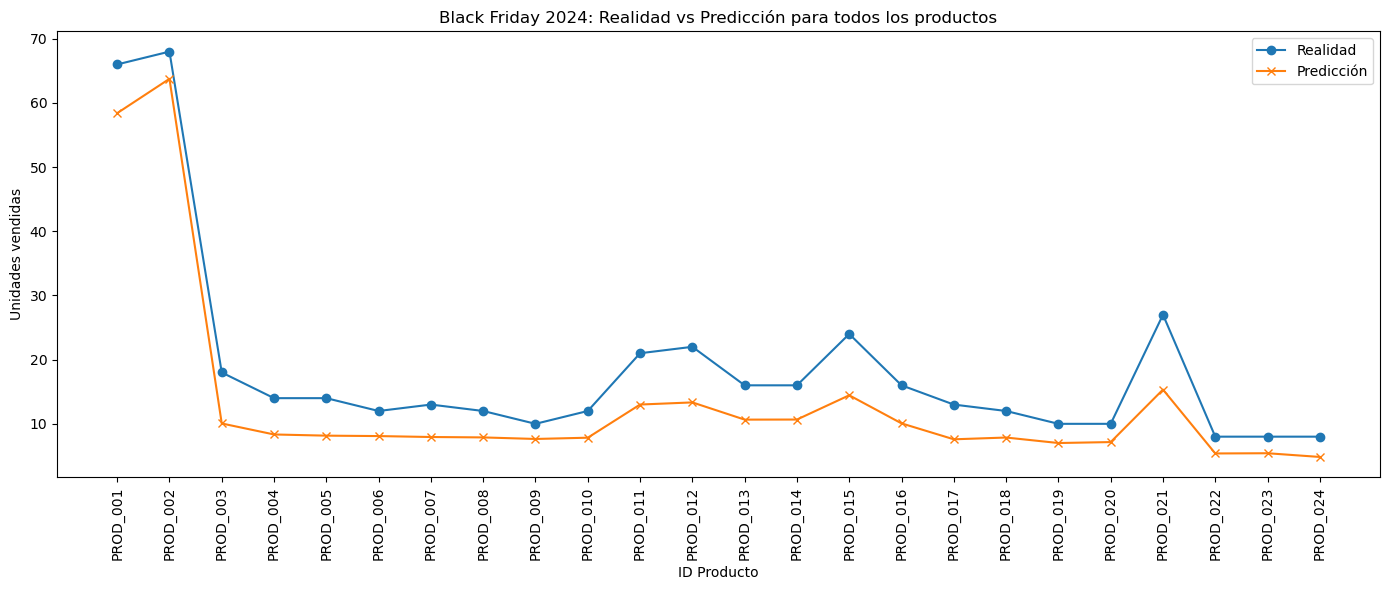

In [39]:
# 🤖 Black Friday 2024: comparación real vs predicho para TODOS los productos (ID producto en eje X)
nov_2024 = pd.date_range(start='2024-11-01', end='2024-11-30', freq='D')
viernes_nov = nov_2024[nov_2024.weekday == 4]
black_friday_2024 = viernes_nov[-1] if len(viernes_nov) > 0 else None

if black_friday_2024 is not None:
    df_bf_all = df_nov2024[df_nov2024['fecha'] == black_friday_2024].copy()
    if df_bf_all.empty:
        print('No hay datos para Black Friday 2024 en el conjunto de validación.')
    else:
        productos_all = df_bf_all[nombre_col].values
        idx_sort = np.argsort(productos_all)
        productos_all_sorted = productos_all[idx_sort]
        y_real_all = df_bf_all['unidades_vendidas'].values[idx_sort]
        X_all = df_bf_all.drop(columns=excluir).iloc[idx_sort]
        y_pred_all = model.predict(X_all)

        plt.figure(figsize=(14,6))
        plt.plot(productos_all_sorted, y_real_all, marker='o', label='Realidad')
        plt.plot(productos_all_sorted, y_pred_all, marker='x', label='Predicción')
        plt.xlabel('ID Producto')
        plt.ylabel('Unidades vendidas')
        plt.title('Black Friday 2024: Realidad vs Predicción para todos los productos')
        plt.legend()
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
else:
    print('No se pudo identificar la fecha de Black Friday 2024.')

In [40]:
# 🤖 Reentrenamiento del modelo final con todos los datos históricos (2021-2024)
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Selección de variables predictoras (igual que antes)
excluir_final = ['fecha', 'ingresos', 'unidades_vendidas']
excluir_final += [col for col in df.columns if df[col].dtype == 'object']
X_full = df.drop(columns=excluir_final)
y_full = df['unidades_vendidas']

# Entrenamiento del modelo final
modelo_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    l2_regularization=1.0,
    random_state=42
)
modelo_final.fit(X_full, y_full)

print('Modelo final entrenado con todos los datos históricos (2021-2024).')

Modelo final entrenado con todos los datos históricos (2021-2024).


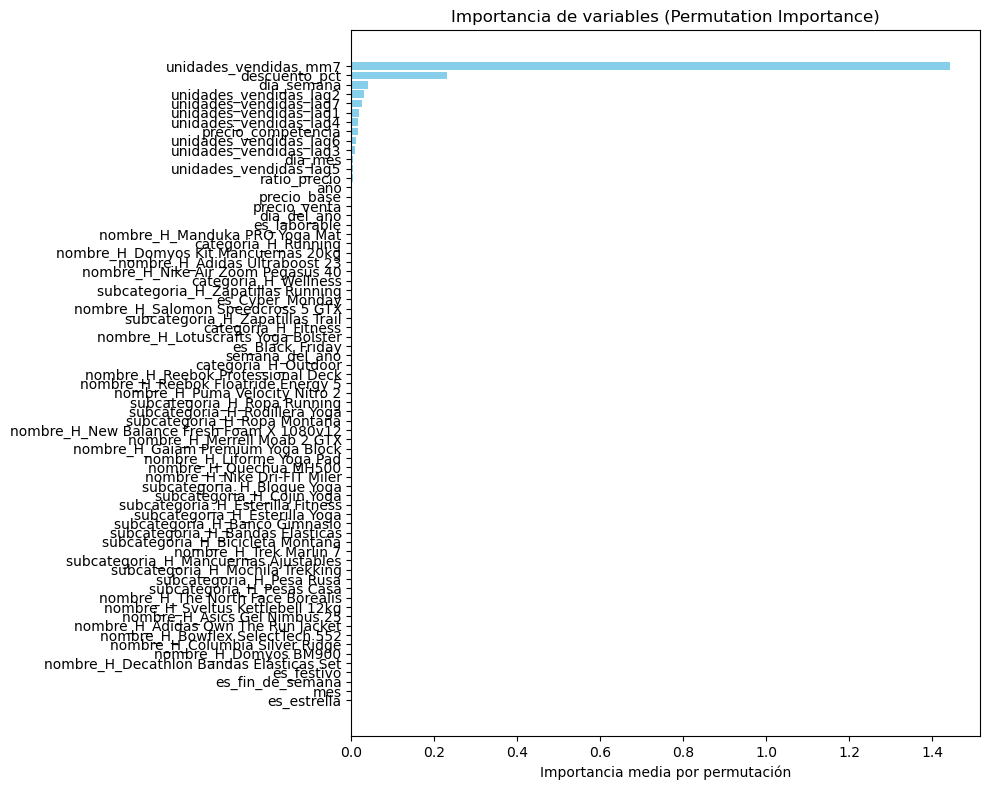

Modelo final guardado en ../models/modelo_final.joblib


In [41]:
# 🤖 Importancia de variables con Permutation Importance y guardado del modelo final
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib

# Calculamos la importancia por permutación (usando el propio set de entrenamiento, ya que no hay test)
result = permutation_importance(modelo_final, X_full, y_full, n_repeats=10, random_state=42, n_jobs=-1)

# Extraemos y ordenamos las importancias
importancias = result.importances_mean
indices = np.argsort(importancias)[::-1]
features = X_full.columns[indices]

# Gráfico de barras horizontales
plt.figure(figsize=(10,8))
plt.barh(features, importancias[indices], color='skyblue')
plt.xlabel('Importancia media por permutación')
plt.title('Importancia de variables (Permutation Importance)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Guardar el modelo final
joblib.dump(modelo_final, '../models/modelo_final.joblib')
print('Modelo final guardado en ../models/modelo_final.joblib')